In [1]:
import pandas as pd 

import seaborn as sns

import matplotlib.pyplot as plt

import numpy as np

sns.set_theme(style="whitegrid")

import statsmodels.api as sm

plt.rc('font', family='NanumGothic') # Windows
plt.rc('axes', unicode_minus=False) # 마이너스 기호 깨짐 방지



In [2]:
df = pd.read_csv("/home/piai/C3_이차전지/bat_process.csv",encoding = "cp949")

In [3]:
pd.set_option('display.max_columns', None)

In [5]:
df.head()

,lot_id,tray_id,cell_id,dt_start,judge,rta1_cell_no,rta1_box_col,rta1_box_row,rta1_box_dan,hta1_box_col,hta1_box_row,hta1_box_dan,rta2_box_col,rta2_box_row,rta2_box_dan,ocv1_ocv,ocv1_box_col,ocv1_box_dan,c1_curr_end,c1_voltage_avg,c1_capa,c1_ccval,c1_time_cc,c1_box_col,c1_box_dan,c1_temp_avg,dc1_curr_end,dc1_voltage_avg,dc1_capa,dc1_box_col,dc1_box_dan,dc1_temp_avg,dc1_capafit,c2_curr_end,c2_voltage_avg,c2_capa,c2_ccval,c2_time_cc,c2_box_col,c2_box_dan,c2_temp_avg,dc2_curr_end,dc2_voltage_avg,dc2_capa,dc2_box_col,dc2_box_dan,dc2_temp_avg,dc2_capafit,c3_curr_end,c3_voltage_avg,c3_capa,c3_ccval,c3_time_cv,c3_cvval,c3_time_cc,c3_box_col,c3_box_dan,c3_temp_avg,dc3_curr_end,dc3_voltage_avg,dc3_capa,dc3_box_col,dc3_box_dan,dc3_temp_avg,dc3_capafit,c4_curr_end,c4_voltage_avg,c4_capa,c4_ccval,c4_time_cv,c4_cvval,c4_time_cc,c4_box_col,c4_box_dan,c4_temp_avg,ocv2_ocv,ocv2_box_col,ocv2_box_dan,pg1_impfit,pg1_imp,pg1_voltage_start,pg1_curr_end,pg1_box_col,pg1_box_dan,pg1_temp_avg,pc1_imp,pc1_voltage_start,pc1_curr_end,pc1_box_col,pc1_box_dan,sa1_box_col,sa1_box_row,sa1_box_dan,socv1_ocv,sa2_box_col,sa2_box_row,sa2_box_dan,socv2_ocv,sa3_box_col,sa3_box_row,sa3_box_dan,socv3_ocv,ocv2_deltaocv,ocv1_deltaocv,m1_thick,m1_voltage,m1_res_ac,m1_mv,m1_voltage_an
0,LOT-100,TRAY-1023,CELL-10747,01SEP24:10:01:25,양품,10,08열,33연,08단,03열,25연,03단,04열,64연,06단,3333,22열,08단,6801,3781,6451,6451,3417,22열,08단,268,6799,4108,544,22열,08단,266,539,6800,4146,625,625,332,22열,08단,265,6799,4112,544,22열,08단,266,539,135,4189,749,578,1190,171,307,22열,08단,266,6796,3674,7094,22열,08단,269,7088,136,3629,4282,4072,1091,210,2157,22열,08단,273,3764,22열,08단,2211,2114,3759,120,12열,01단,288,2086,3714,150,12열,01단,09열,42연,01단,3766.1,03열,64연,05단,3761.1,14열,37연,04단,3759.3,5.0,6.8,4718.0,37583.0,94.0,565.0,164.0
1,LOT-100,TRAY-1023,CELL-10748,01SEP24:10:01:25,양품,7,08열,33연,08단,03열,25연,03단,04열,64연,06단,3329,22열,08단,6797,3783,6390,6390,3385,22열,08단,268,6800,4103,545,22열,08단,266,540,6802,4144,657,657,349,22열,08단,265,6800,4110,544,22열,08단,266,539,136,4189,768,588,1286,180,313,22열,08단,266,6799,3674,7091,22열,08단,269,7085,136,3624,4268,4064,969,204,2153,22열,08단,273,3763,22열,08단,2224,2127,3758,120,12열,01단,288,2093,3714,150,12열,01단,09열,42연,01단,3765.2,03열,64연,05단,3760.2,14열,37연,04단,3758.4,5.0,6.8,4718.0,37574.0,94.0,565.0,73.0
2,LOT-100,TRAY-1023,CELL-10749,01SEP24:10:01:25,양품,19,08열,33연,08단,03열,25연,03단,04열,64연,06단,3329,22열,08단,6798,3781,6436,6436,3410,22열,08단,268,6799,4107,544,22열,08단,266,539,6801,4146,630,630,335,22열,08단,265,6799,4111,544,22열,08단,266,539,136,4189,753,579,1228,174,308,22열,08단,266,6799,3674,7079,22열,08단,269,7073,136,3630,4270,4058,1112,212,2150,22열,08단,273,3764,22열,08단,2217,2120,3759,120,12열,01단,288,2081,3715,150,12열,01단,09열,42연,01단,3765.9,03열,64연,05단,3760.8,14열,37연,04단,3759.0,5.1,6.9,4700.0,37579.0,91.0,585.0,-57.0
3,LOT-100,TRAY-1023,CELL-10750,01SEP24:10:01:25,양품,24,08열,33연,08단,03열,25연,03단,04열,64연,06단,3330,22열,08단,6799,3781,6474,6474,3430,22열,08단,268,6800,4108,545,22열,08단,266,540,6801,4146,627,627,333,22열,08단,265,6799,4111,544,22열,08단,266,539,136,4190,765,583,1328,182,310,22열,08단,266,6796,3675,7106,22열,08단,269,7100,136,3630,4304,4092,1129,212,2168,22열,08단,273,3764,22열,08단,2214,2117,3759,119,12열,01단,288,2083,3714,150,12열,01단,09열,42연,01단,3766.4,03열,64연,05단,3761.3,14열,37연,04단,3759.5,5.1,6.9,4688.0,37583.0,93.0,606.0,99.0
4,LOT-100,TRAY-1023,CELL-10751,01SEP24:10:01:25,양품,17,08열,33연,08단,03열,25연,03단,04열,64연,06단,3330,22열,08단,6799,3780,6486,6486,3436,22열,08단,268,6798,4110,544,22열,08단,266,539,6800,4147,613,613,326,22열,08단,265,6799,4112,544,22열,08단,266,539,136,4187,733,575,980,159,306,22열,08단,266,6797,3674,7101,22열,08단,269,7095,136,3619,4286,4088,879,199,2166,22열,08단,273,3762,22열,08단,2221,2124,3758,120,12열,01단,288,2083,3714,150,12열,01단,09열,42연,01단,3765.0,03열,64연,05단,3760.0,14열,37연,04단,3758.2,5.0,6.8,4696.0,37570.0,91.0,605.0,36.0


In [5]:
# 67번째 열(인덱스 66)부터 88번째 열(인덱스 87)까지 선택
df_은혁 = df.iloc[:, 66:88]


In [6]:
df_은혁

,c4_voltage_avg,c4_capa,c4_ccval,c4_time_cv,c4_cvval,c4_time_cc,c4_box_col,c4_box_dan,c4_temp_avg,ocv2_ocv,ocv2_box_col,ocv2_box_dan,pg1_impfit,pg1_imp,pg1_voltage_start,pg1_curr_end,pg1_box_col,pg1_box_dan,pg1_temp_avg,pc1_imp,pc1_voltage_start,pc1_curr_end
0,3629,4282,4072,1091,210,2157,22열,08단,273,3764,22열,08단,2211,2114,3759,120,12열,01단,288,2086,3714,150
1,3624,4268,4064,969,204,2153,22열,08단,273,3763,22열,08단,2224,2127,3758,120,12열,01단,288,2093,3714,150
2,3630,4270,4058,1112,212,2150,22열,08단,273,3764,22열,08단,2217,2120,3759,120,12열,01단,288,2081,3715,150
3,3630,4304,4092,1129,212,2168,22열,08단,273,3764,22열,08단,2214,2117,3759,119,12열,01단,288,2083,3714,150
4,3619,4286,4088,879,199,2166,22열,08단,273,3762,22열,08단,2221,2124,3758,120,12열,01단,288,2083,3714,150
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38590,3619,4265,4063,861,202,2153,02열,05단,255,3762,02열,05단,2250,2192,3759,120,08열,01단,275,2137,3714,150
38591,3616,4276,4077,813,199,2161,02열,05단,255,3762,02열,05단,2272,2214,3759,119,08열,01단,275,2151,3714,150
38592,3633,4272,4050,1157,222,2146,02열,05단,255,3764,02열,05단,2282,2224,3759,119,08열,01단,275,2149,3715,150
38593,3630,4261,4042,1078,219,2142,02열,05단,255,3764,02열,05단,2272,2214,3759,119,08열,01단,275,2160,3714,150


In [7]:
df_은혁.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38595 entries, 0 to 38594
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   c4_voltage_avg     38595 non-null  int64 
 1   c4_capa            38595 non-null  int64 
 2   c4_ccval           38595 non-null  int64 
 3   c4_time_cv         38595 non-null  int64 
 4   c4_cvval           38595 non-null  int64 
 5   c4_time_cc         38595 non-null  int64 
 6   c4_box_col         38595 non-null  object
 7   c4_box_dan         38595 non-null  object
 8   c4_temp_avg        38595 non-null  int64 
 9   ocv2_ocv           38595 non-null  int64 
 10  ocv2_box_col       38595 non-null  object
 11  ocv2_box_dan       38595 non-null  object
 12  pg1_impfit         38595 non-null  int64 
 13  pg1_imp            38595 non-null  int64 
 14  pg1_voltage_start  38595 non-null  int64 
 15  pg1_curr_end       38595 non-null  int64 
 16  pg1_box_col        38595 non-null  objec

In [8]:
# int64 타입의 열만 선택하여 df_int에 저장
df_은혁_int = df_은혁.select_dtypes(include=['int64'])

In [9]:
# object 타입의 열만 선택하여 df_object에 저장
df_은혁_object = df_은혁.select_dtypes(include=['object'])


In [10]:
df_은혁_int.head()

,c4_voltage_avg,c4_capa,c4_ccval,c4_time_cv,c4_cvval,c4_time_cc,c4_temp_avg,ocv2_ocv,pg1_impfit,pg1_imp,pg1_voltage_start,pg1_curr_end,pg1_temp_avg,pc1_imp,pc1_voltage_start,pc1_curr_end
0,3629,4282,4072,1091,210,2157,273,3764,2211,2114,3759,120,288,2086,3714,150
1,3624,4268,4064,969,204,2153,273,3763,2224,2127,3758,120,288,2093,3714,150
2,3630,4270,4058,1112,212,2150,273,3764,2217,2120,3759,120,288,2081,3715,150
3,3630,4304,4092,1129,212,2168,273,3764,2214,2117,3759,119,288,2083,3714,150
4,3619,4286,4088,879,199,2166,273,3762,2221,2124,3758,120,288,2083,3714,150


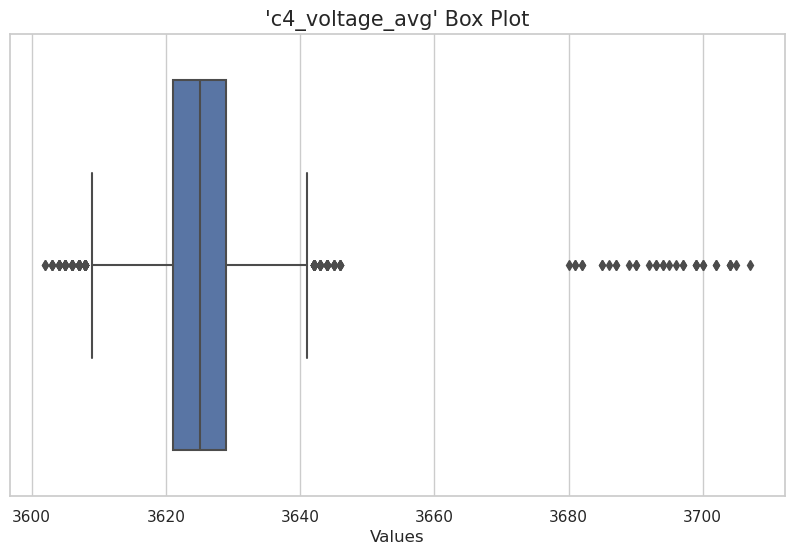

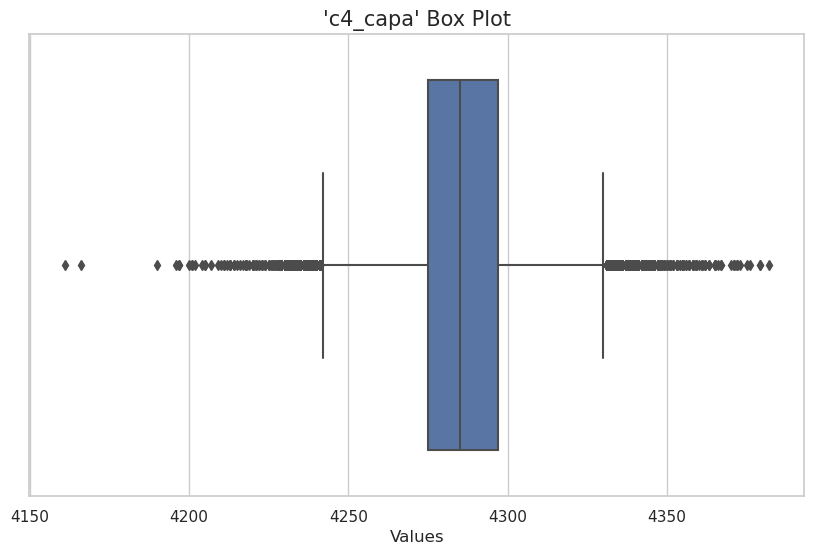

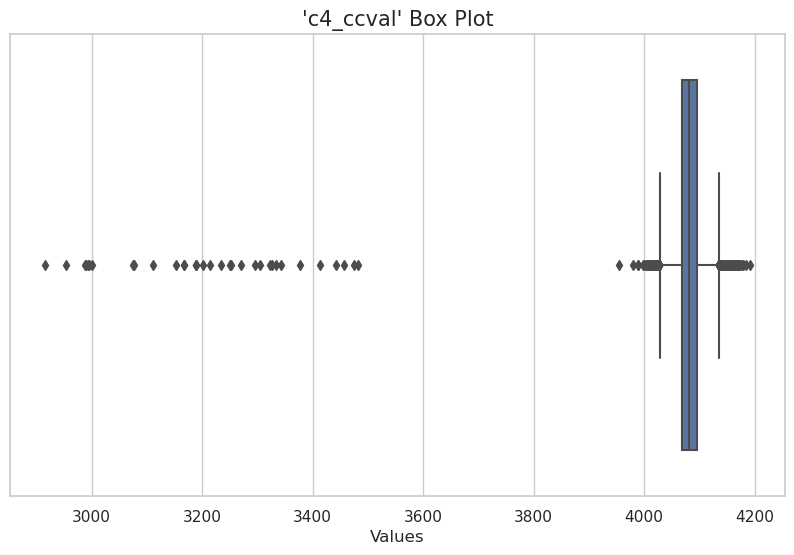

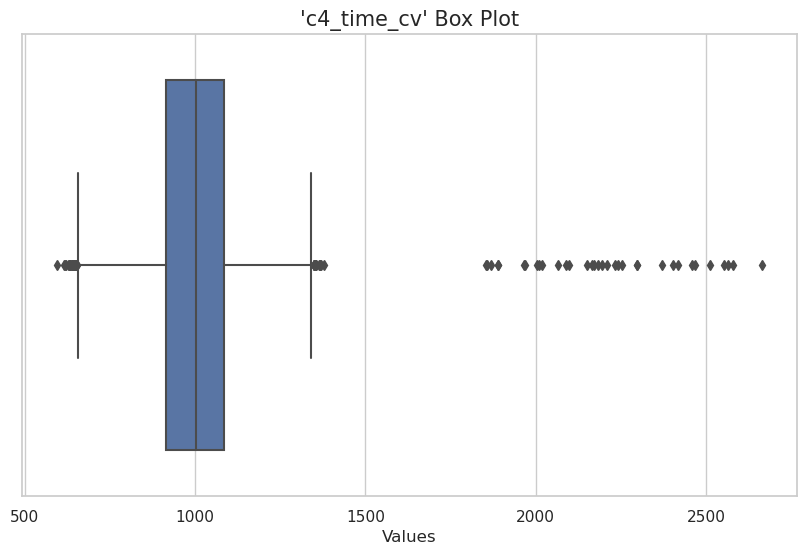

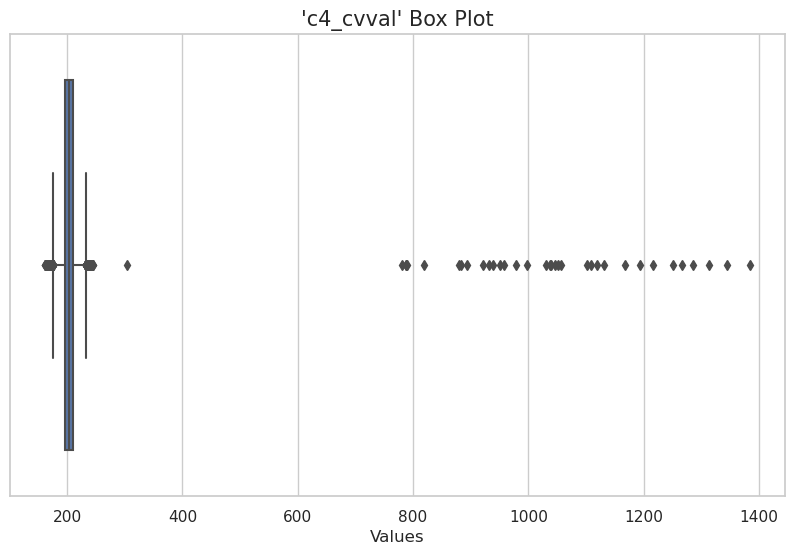

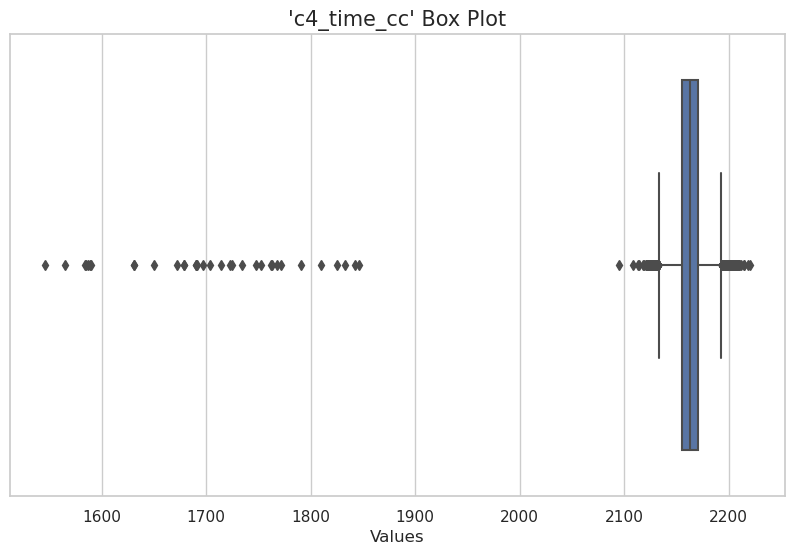

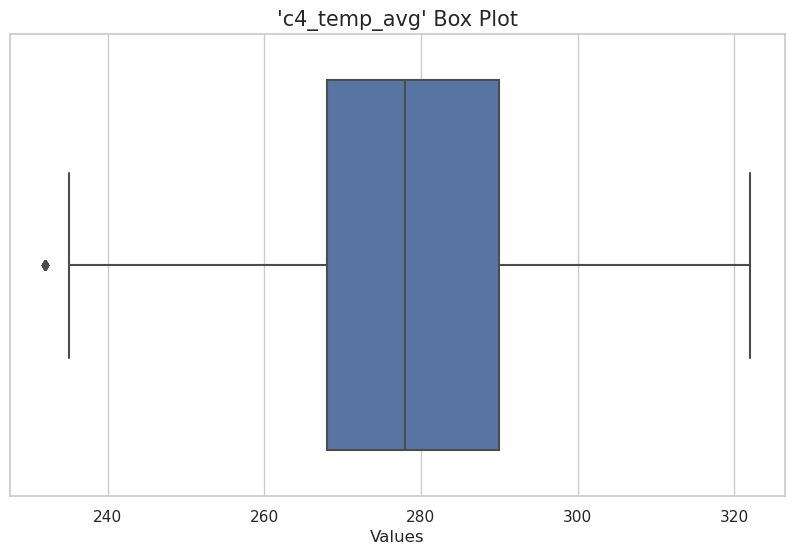

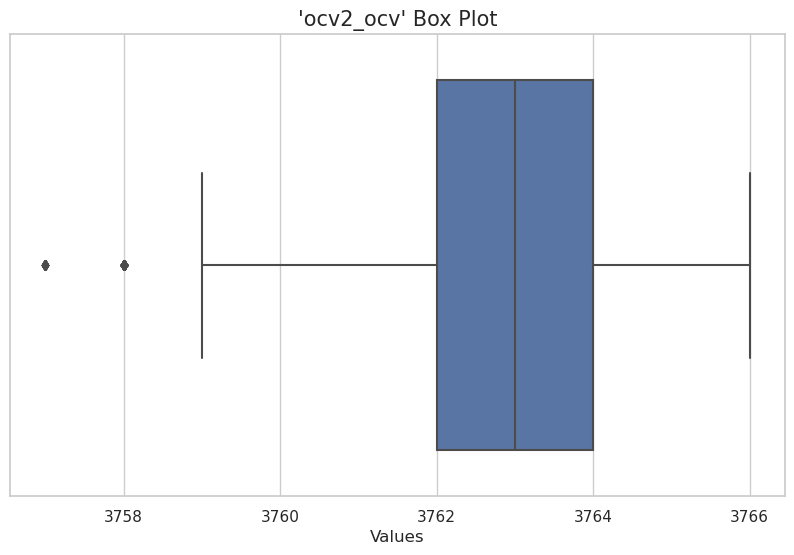

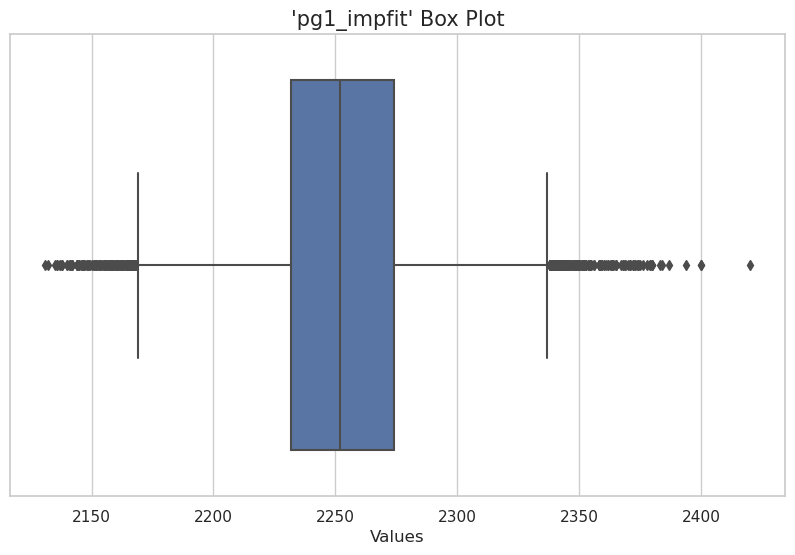

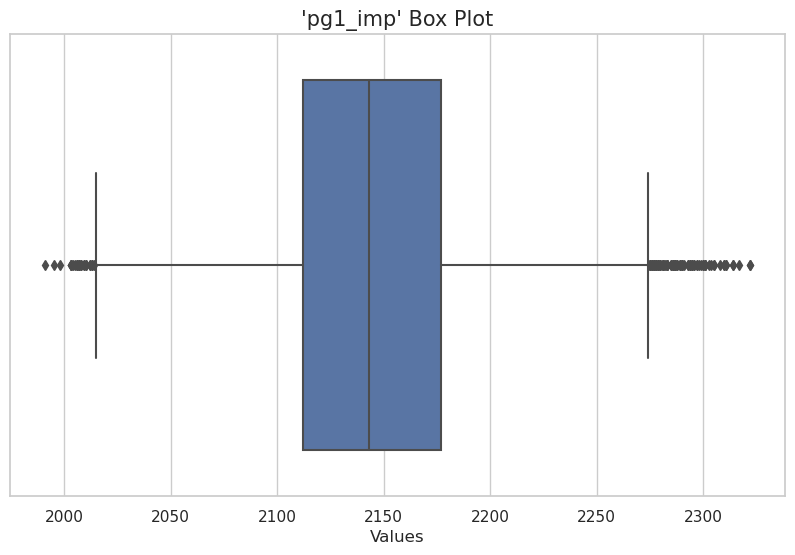

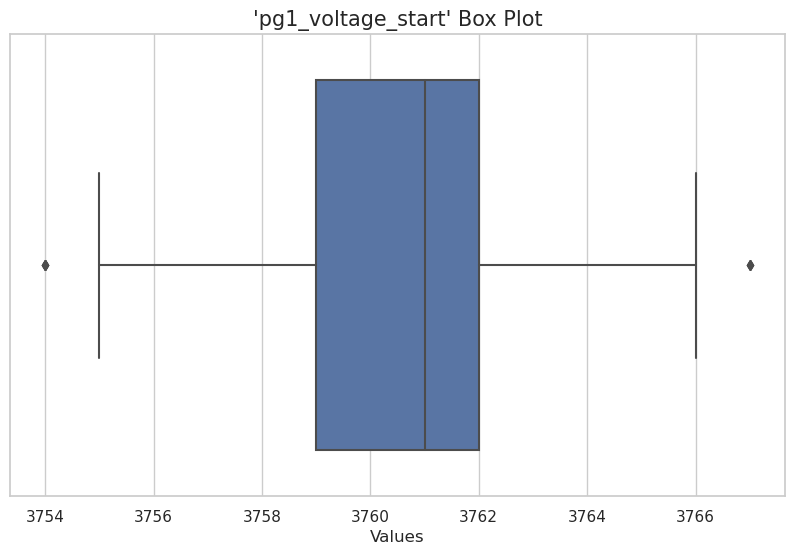

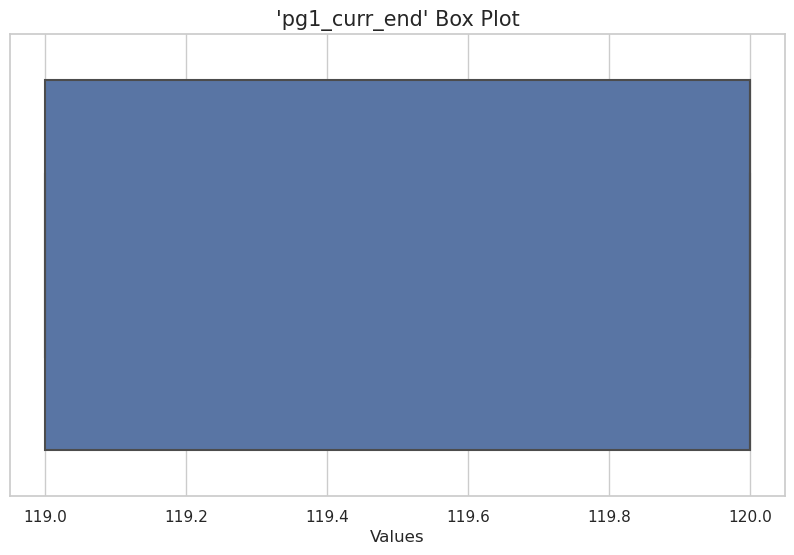

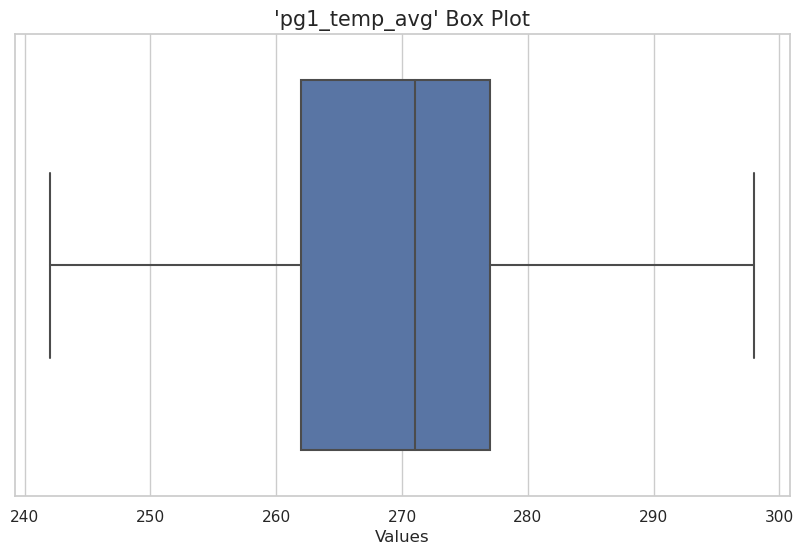

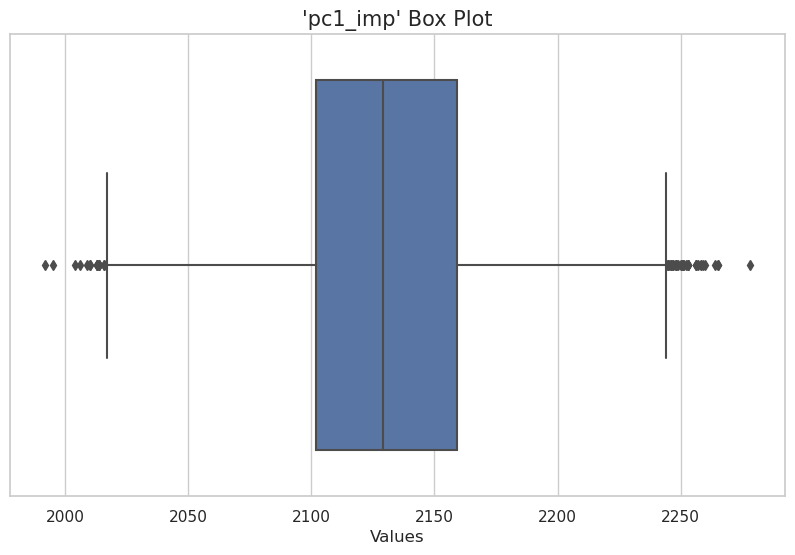

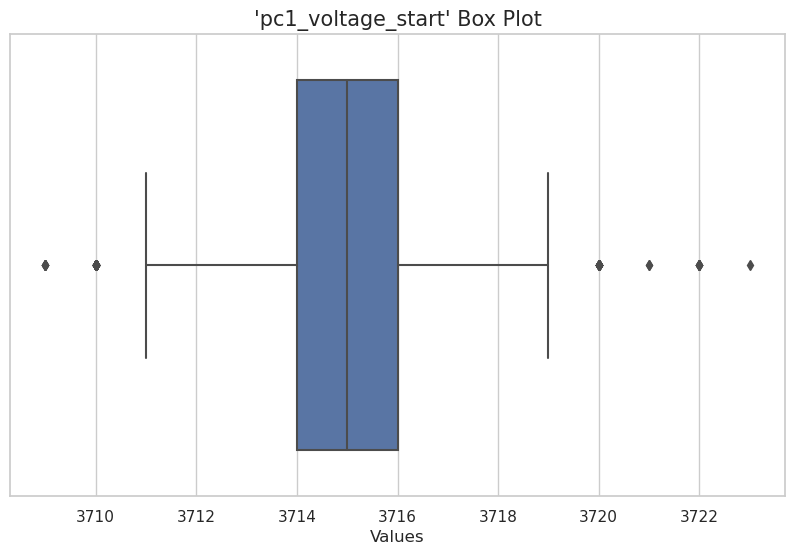

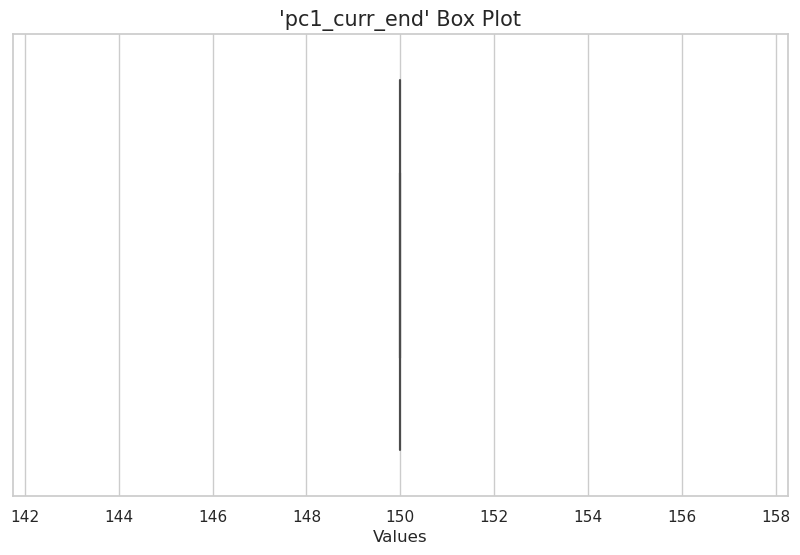

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn 스타일 설정
sns.set_theme(style="whitegrid")

# 시작 컬럼과 끝 컬럼 이름 정의
start_column = 'c4_voltage_avg'
end_column = 'pc1_curr_end'

# .loc를 사용하여 시작 컬럼부터 끝 컬럼까지의 모든 컬럼 이름을 선택합니다.
columns_to_plot = df_은혁_int.loc[:, start_column:end_column].columns

# 선택된 각 컬럼에 대해 반복문 실행
for column in columns_to_plot:
    plt.figure(figsize=(10, 6))  # 각 그래프를 독립된 그림으로 생성
    sns.boxplot(x=df_은혁_int[column])
    plt.title(f"'{column}' Box Plot", fontsize=15) # f-string을 사용해 각 그래프에 맞는 제목 설정
    plt.xlabel("Values", fontsize=12)
    plt.show() # 각 그래프를 바로 출력


각 컬럼별 분포 및 치우침 시각화 (Histogram + KDE)


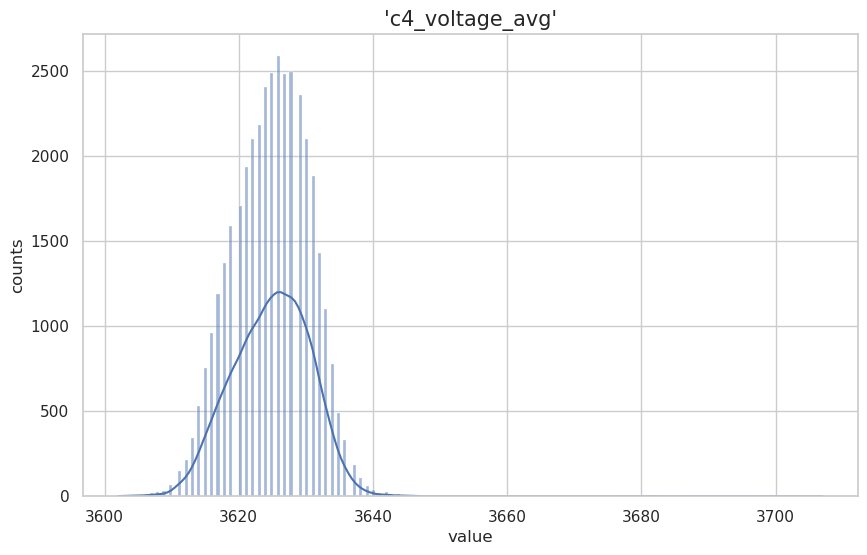

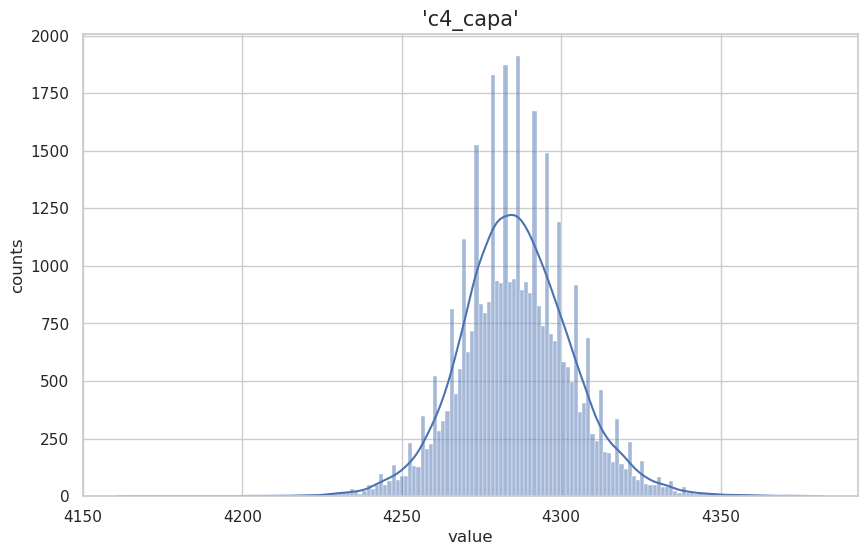

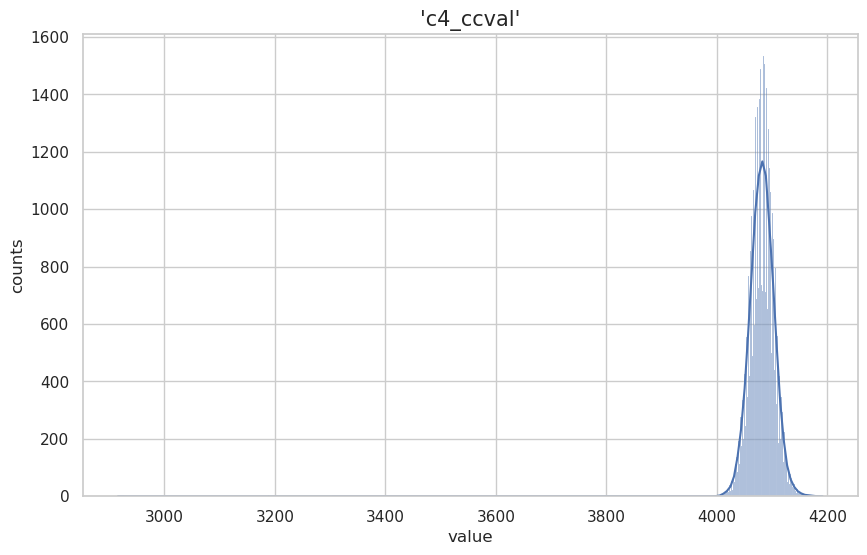

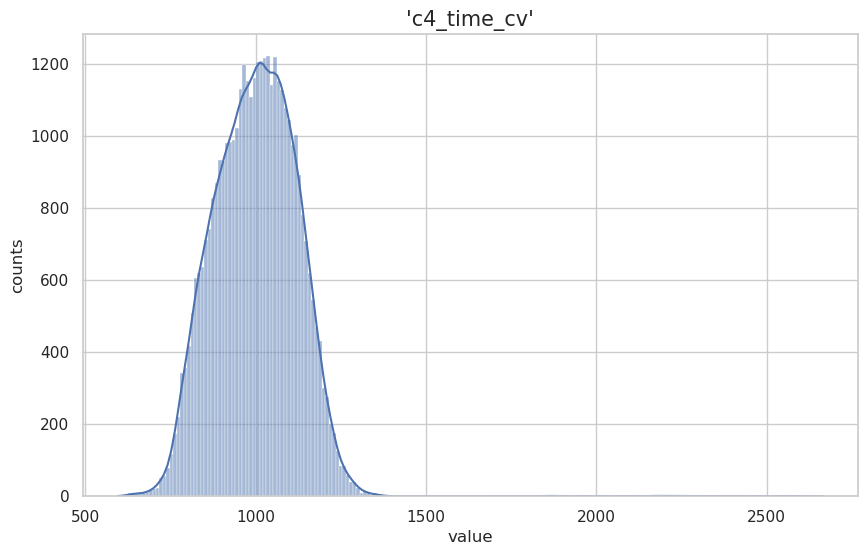

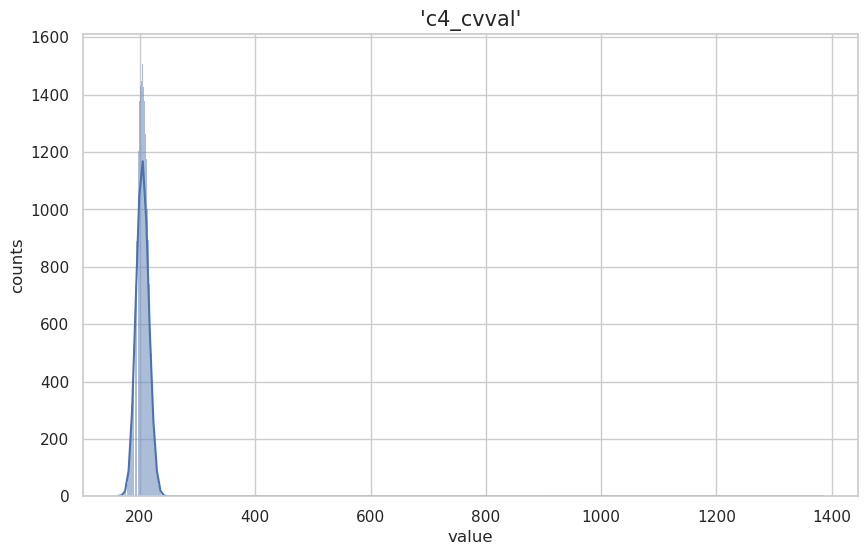

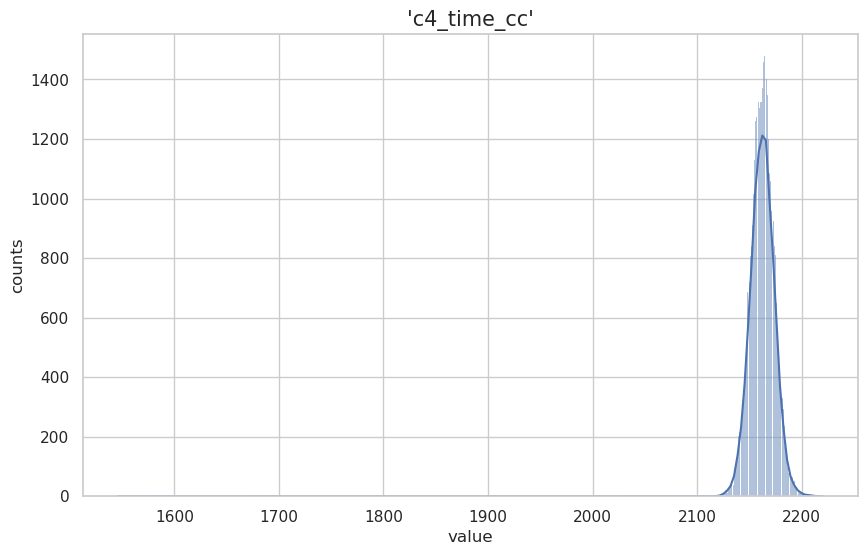

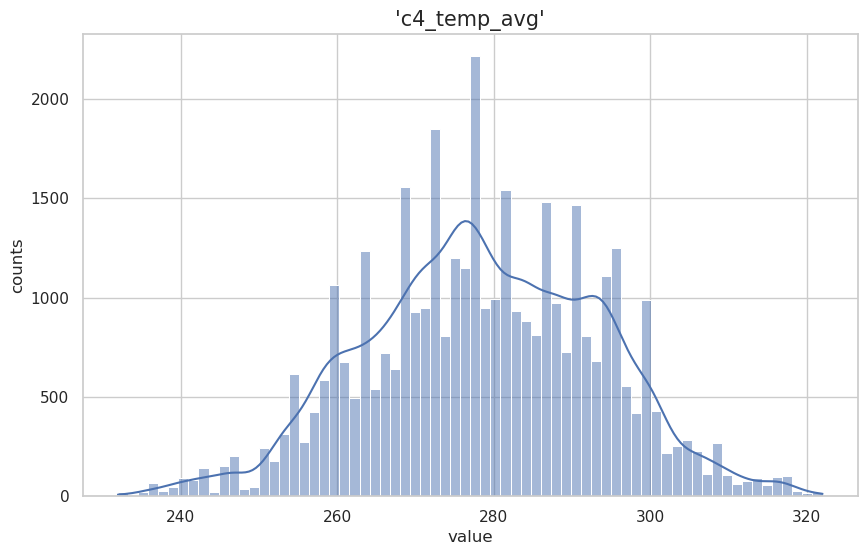

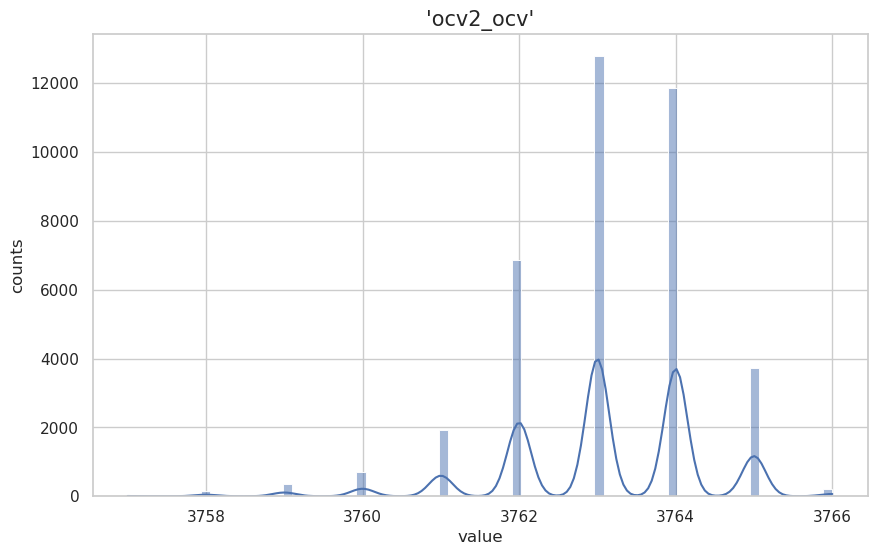

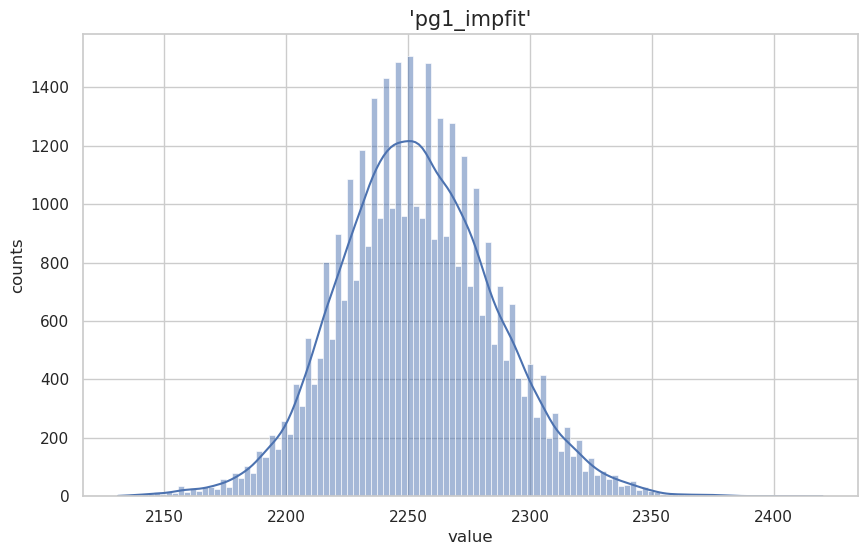

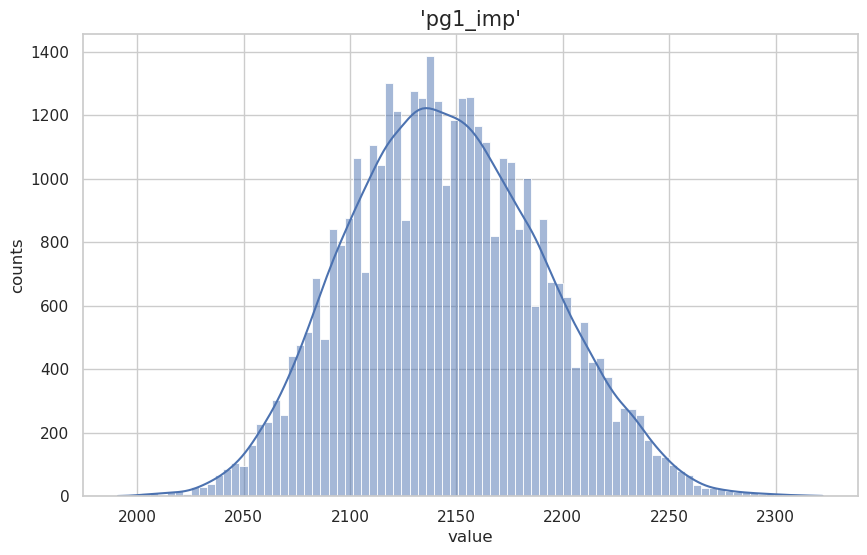

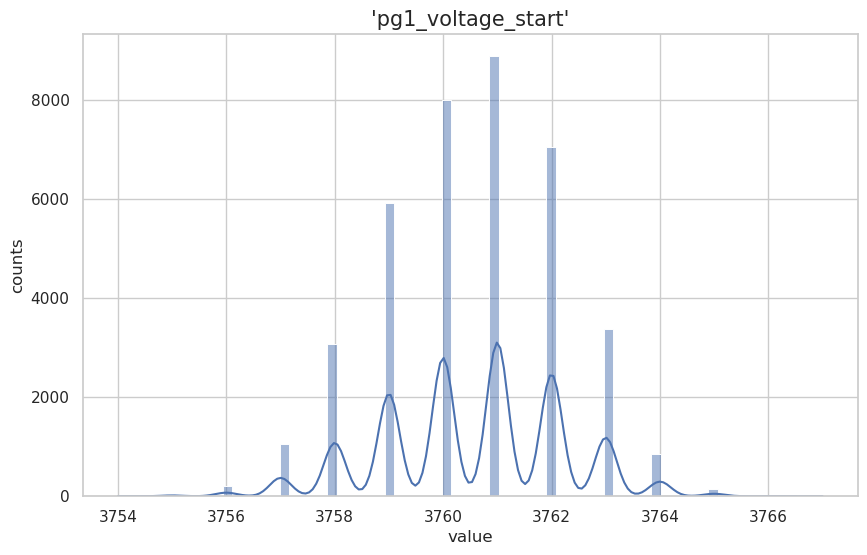

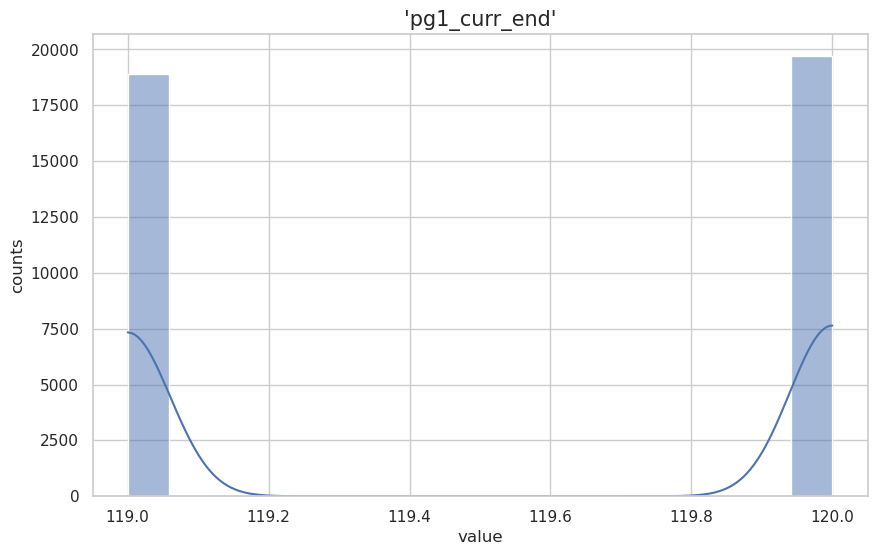

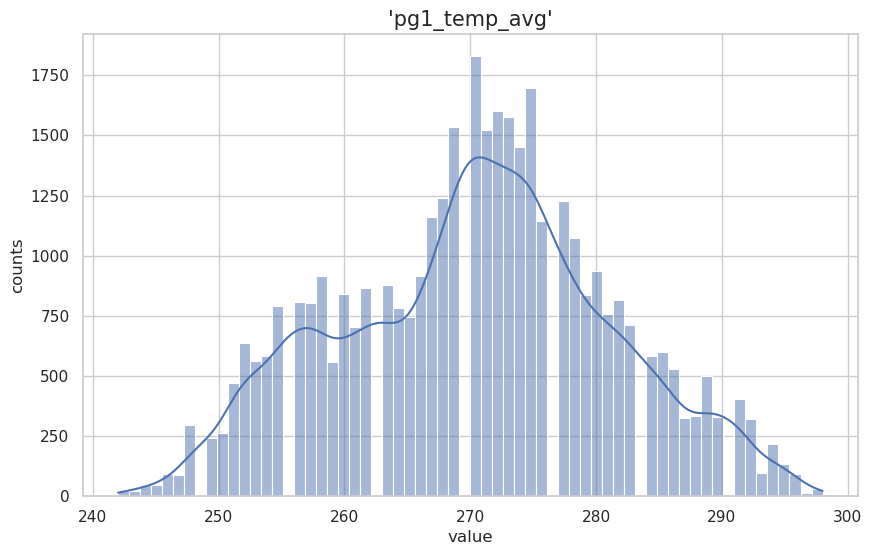

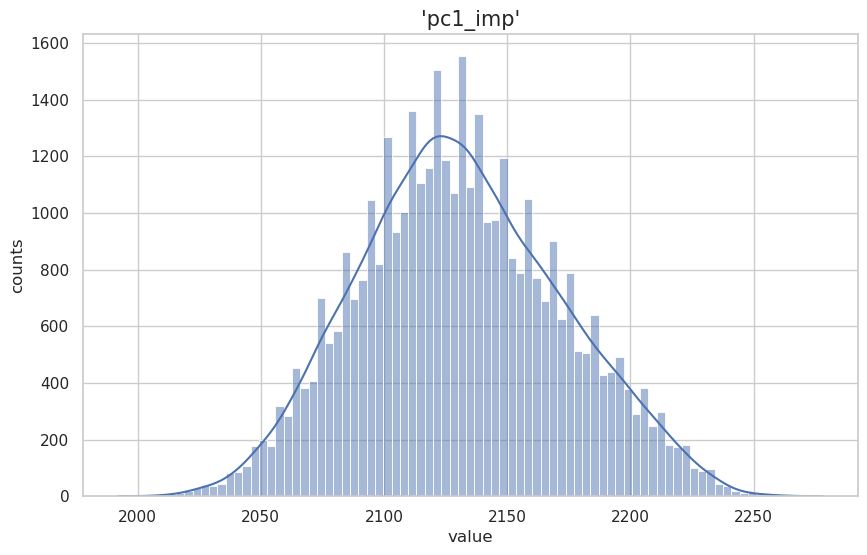

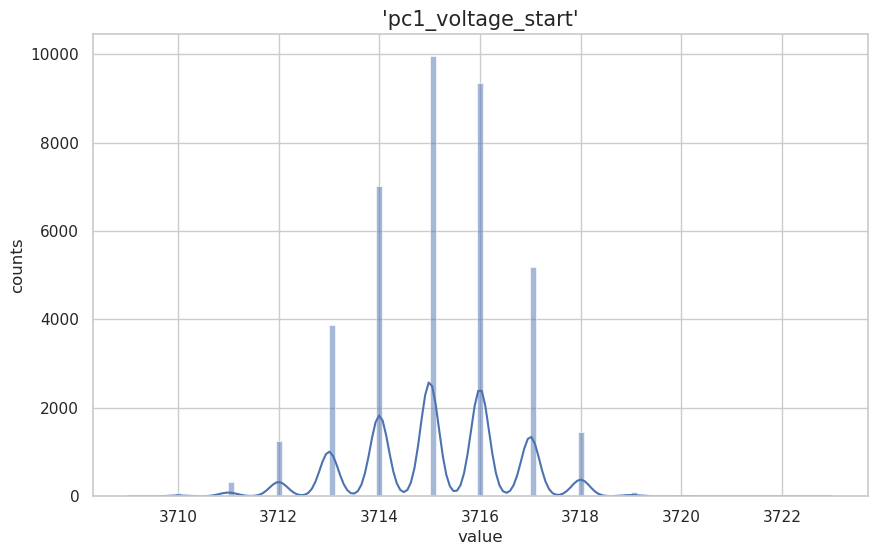

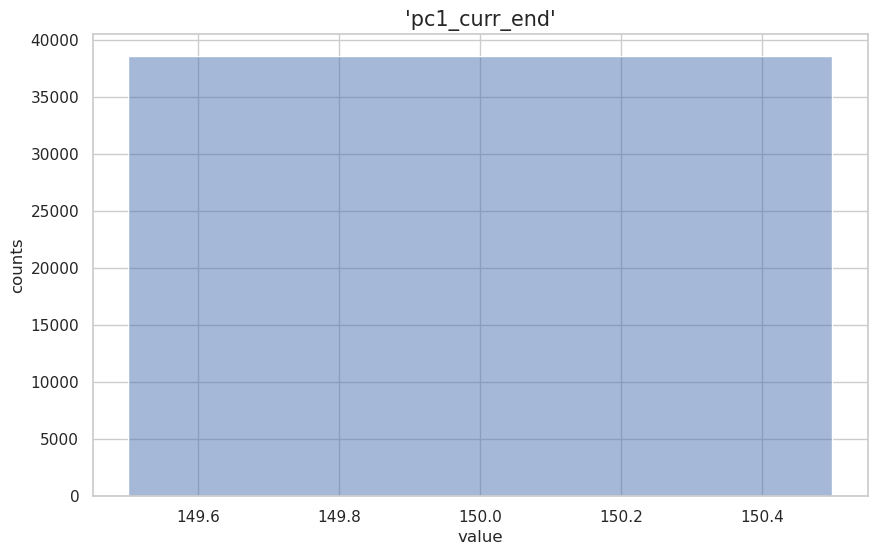

In [12]:


# 시작 컬럼과 끝 컬럼 이름 정의
start_column = 'c4_voltage_avg'
end_column = 'pc1_curr_end'

# .loc를 사용하여 분석할 컬럼 이름 목록을 가져옵니다.
columns_to_check = df_은혁_int.loc[:, start_column:end_column].columns

print("="*50)
print("각 컬럼별 분포 및 치우침 시각화 (Histogram + KDE)")
print("="*50)

# 선택된 각 컬럼에 대해 반복문 실행
for column in columns_to_check:
    plt.figure(figsize=(10, 6))
    # kde=True 옵션으로 밀도 추정 곡선을 함께 그립니다.
    sns.histplot(df_은혁_int[column], kde=True)
    plt.title(f"'{column}'", fontsize=15)
    plt.xlabel("value", fontsize=12)
    plt.ylabel("counts", fontsize=12)
    plt.show()


In [13]:


# 시작 컬럼과 끝 컬럼 이름 정의
start_column = 'c4_voltage_avg'
end_column = 'pc1_curr_end'

# .loc를 사용하여 분석할 컬럼 이름 목록을 가져옵니다.
columns_to_check = df_은혁_int.loc[:, start_column:end_column].columns

# 각 컬럼별 이상치 정보를 저장할 딕셔너리 생성
outlier_info = {}


# 선택된 각 컬럼에 대해 반복문 실행
for col in columns_to_check:
    # 1. 특정 컬럼에 대한 Q1, Q3, IQR 계산
    Q1 = df_은혁_int[col].quantile(0.25)
    Q3 = df_은혁_int[col].quantile(0.75)
    IQR = Q3 - Q1

    # 2. 이상치 경계 계산
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # 3. 이상치 데이터 필터링 및 인덱스 추출
    outlier_indices = df_은혁_int[(df_은혁_int[col] < lower_bound) | (df_은혁_int[col] > upper_bound)].index
    
    # 4. 이상치 개수 계산
    outlier_count = len(outlier_indices)

    # 6. 결과 저장 (이상치 경계값 추가)
    outlier_info[col] = {
        'count': outlier_count,
        'lower_bound': lower_bound, # 이상치 하한 기준 저장
        'upper_bound': upper_bound, # 이상치 상한 기준 저장
        'indices': outlier_indices.tolist()
    }


# 분석 결과를 DataFrame으로 변환
outlier_summary_df = pd.DataFrame(outlier_info).T

# 이상치 개수를 기준으로 내림차순 정렬
outlier_summary_df = outlier_summary_df.sort_values(by='count', ascending=False)

# 최종 결과 출력 (이상치 기준 컬럼 포함)
print("\n--- 이상치 요약 테이블 (이상치 기준 포함) ---")
# 'indices' 컬럼은 내용이 너무 길 수 있으므로 제외하고 출력합니다.
print(outlier_summary_df[['count', 'lower_bound', 'upper_bound']])



--- 이상치 요약 테이블 (이상치 기준 포함) ---
                  count lower_bound upper_bound
c4_capa             720      4242.0      4330.0
c4_ccval            584      4027.5      4135.5
pg1_impfit          464      2169.0      2337.0
c4_time_cc          459      2132.5      2192.5
c4_cvval            221       176.0       232.0
ocv2_ocv            167      3759.0      3767.0
c4_voltage_avg      159      3609.0      3641.0
pg1_imp             120      2014.5      2274.5
pc1_voltage_start   103      3711.0      3719.0
c4_time_cv           73       656.0      1344.0
pc1_imp              59      2016.5      2244.5
c4_temp_avg          20       235.0       323.0
pg1_voltage_start     7      3754.5      3766.5
pg1_curr_end          0       117.5       121.5
pg1_temp_avg          0       239.5       299.5
pc1_curr_end          0       150.0       150.0


In [14]:
df_은혁_int[["pg1_curr_end","pg1_temp_avg","pc1_curr_end"]].describe()

,pg1_curr_end,pg1_temp_avg,pc1_curr_end
count,38595.000000,38595.000000,38595.0
mean,119.510299,270.340640,150.0
std,0.499900,10.866277,0.0
min,119.000000,242.000000,150.0
25%,119.000000,262.000000,150.0
50%,120.000000,271.000000,150.0
75%,120.000000,277.000000,150.0
max,120.000000,298.000000,150.0


In [15]:
df_은혁_int["pg1_curr_end"].unique()

array([120, 119])

In [ ]:
df_은혁_int["pc1_voltage_start"].value_counts().

3715    9952
3716    9340
3714    7027
3717    5187
3713    3881
3718    1444
3712    1239
3711     320
3719     102
3710      64
3720      23
3722       7
3709       6
3721       2
3723       1
Name: pc1_voltage_start, dtype: int64

In [16]:
df_은혁_object

,c4_box_col,c4_box_dan,ocv2_box_col,ocv2_box_dan,pg1_box_col,pg1_box_dan
0,22열,08단,22열,08단,12열,01단
1,22열,08단,22열,08단,12열,01단
2,22열,08단,22열,08단,12열,01단
3,22열,08단,22열,08단,12열,01단
4,22열,08단,22열,08단,12열,01단
...,...,...,...,...,...,...
38590,02열,05단,02열,05단,08열,01단
38591,02열,05단,02열,05단,08열,01단
38592,02열,05단,02열,05단,08열,01단
38593,02열,05단,02열,05단,08열,01단


In [17]:

# 시작 컬럼과 끝 컬럼 이름 정의 (제공된 스니펫)
start_column = 'c4_box_col'
end_column = 'pg1_box_dan'

# .loc를 사용하여 분석할 컬럼 이름 목록을 가져옵니다.
columns_to_test = df_은혁_object.loc[:, start_column:end_column].columns

print("=" * 50)
print(f"'{start_column}'부터 '{end_column}'까지 각 컬럼의 고유값(Unique Values)")
print("=" * 50)

# 선택된 각 컬럼에 대해 반복문 실행
for col in columns_to_test:
    # 1. 해당 컬럼의 고유값 추출
    unique_values = df_은혁_object[col].unique()
    
    # 2. 고유값의 개수 계산
    num_unique = len(unique_values)
    
    # 3. 결과 출력
    print(f"\n--- 컬럼명: '{col}' ---")
    print(f"고유값 개수: {num_unique}개")
    

    sorted_values = np.sort(unique_values)
    print(f"고유값 목록: {sorted_values}")
        




'c4_box_col'부터 'pg1_box_dan'까지 각 컬럼의 고유값(Unique Values)

--- 컬럼명: 'c4_box_col' ---
고유값 개수: 22개
고유값 목록: ['01열' '02열' '03열' '04열' '05열' '06열' '07열' '08열' '09열' '10열' '11열' '12열'
 '13열' '14열' '15열' '16열' '17열' '18열' '19열' '20열' '21열' '22열']

--- 컬럼명: 'c4_box_dan' ---
고유값 개수: 11개
고유값 목록: ['01단' '02단' '03단' '04단' '05단' '06단' '07단' '08단' '09단' '10단' '11단']

--- 컬럼명: 'ocv2_box_col' ---
고유값 개수: 22개
고유값 목록: ['01열' '02열' '03열' '04열' '05열' '06열' '07열' '08열' '09열' '10열' '11열' '12열'
 '13열' '14열' '15열' '16열' '17열' '18열' '19열' '20열' '21열' '22열']

--- 컬럼명: 'ocv2_box_dan' ---
고유값 개수: 11개
고유값 목록: ['01단' '02단' '03단' '04단' '05단' '06단' '07단' '08단' '09단' '10단' '11단']

--- 컬럼명: 'pg1_box_col' ---
고유값 개수: 10개
고유값 목록: ['01열' '02열' '04열' '05열' '06열' '07열' '08열' '09열' '10열' '12열']

--- 컬럼명: 'pg1_box_dan' ---
고유값 개수: 1개
고유값 목록: ['01단']


pg1_box_col 왜 3열과 11열 대신 12열이 있는가?

In [18]:
object_cols = df_은혁_object.select_dtypes(include=['object']).columns

if len(object_cols) == 0:
    print("df_은혁_object에서 확인할 범주형(object) 컬럼이 없습니다.")
else:
    print("="*50)
    print("df_은혁_object의 범주형 컬럼별 빈도수 분석")
    print("="*50)

    # 2. 선택된 각 컬럼에 대해 반복 실행
    for col in object_cols:
        print(f"\n===== 컬럼명: '{col}' =====")
        
        # 3. value_counts()를 호출하여 빈도수 확인
        value_counts = df_은혁_object[col].value_counts()
        
        print(value_counts)
        
        # 빈도가 매우 낮은 값(예: 5개 미만)을 '이상치'로 간주하고 출력
        rare_categories = value_counts[value_counts < 5]
        if not rare_categories.empty:
            print("\n--- 희귀 범주 (빈도 5 미만) ---")
            print(rare_categories)

    print("\n" + "="*50)
    print("분석이 완료되었습니다.")
    print("="*50)


df_은혁_object의 범주형 컬럼별 빈도수 분석

===== 컬럼명: 'c4_box_col' =====
22열    2633
19열    2013
20열    1988
11열    1941
13열    1908
07열    1892
14열    1848
21열    1844
02열    1827
08열    1804
12열    1781
16열    1746
17열    1737
18열    1706
10열    1662
01열    1659
09열    1608
06열    1550
03열    1504
15열    1503
05열    1356
04열    1085
Name: c4_box_col, dtype: int64

===== 컬럼명: 'c4_box_dan' =====
04단    4214
07단    4194
05단    4172
02단    3818
06단    3630
03단    3521
11단    3470
08단    3366
09단    3349
10단    3157
01단    1704
Name: c4_box_dan, dtype: int64

===== 컬럼명: 'ocv2_box_col' =====
22열    2633
19열    2013
20열    1988
11열    1941
13열    1908
07열    1892
14열    1848
21열    1844
02열    1827
08열    1804
12열    1781
16열    1746
17열    1737
18열    1706
10열    1662
01열    1659
09열    1608
06열    1550
03열    1504
15열    1503
05열    1356
04열    1085
Name: ocv2_box_col, dtype: int64

===== 컬럼명: 'ocv2_box_dan' =====
04단    4214
07단    4194
05단    4172
02단    3818
06단    3630
03단    3521
11단    3470
08단 

In [19]:


# 시작 컬럼과 끝 컬럼 이름 정의
start_column = 'c4_box_col'
end_column = 'pg1_box_dan'


# .loc를 사용하여 분석할 컬럼 이름 목록을 가져옵니다.
columns_to_check = df_은혁_object.loc[:, start_column:end_column].columns

print("=" * 60)
print(f"'{start_column}'부터 '{end_column}'까지 각 컬럼의 고유값 빈도 분석")
print("=" * 60)

# 선택된 각 컬럼에 대해 반복문 실행
for col in columns_to_check:
    print(f"\n===== 컬럼명: '{col}' =====")
    # value_counts()를 호출하여 고유값과 그 빈도를 확인합니다.
    value_counts = df_은혁_object[col].value_counts()
    print(value_counts)
    

'c4_box_col'부터 'pg1_box_dan'까지 각 컬럼의 고유값 빈도 분석

===== 컬럼명: 'c4_box_col' =====
22열    2633
19열    2013
20열    1988
11열    1941
13열    1908
07열    1892
14열    1848
21열    1844
02열    1827
08열    1804
12열    1781
16열    1746
17열    1737
18열    1706
10열    1662
01열    1659
09열    1608
06열    1550
03열    1504
15열    1503
05열    1356
04열    1085
Name: c4_box_col, dtype: int64

===== 컬럼명: 'c4_box_dan' =====
04단    4214
07단    4194
05단    4172
02단    3818
06단    3630
03단    3521
11단    3470
08단    3366
09단    3349
10단    3157
01단    1704
Name: c4_box_dan, dtype: int64

===== 컬럼명: 'ocv2_box_col' =====
22열    2633
19열    2013
20열    1988
11열    1941
13열    1908
07열    1892
14열    1848
21열    1844
02열    1827
08열    1804
12열    1781
16열    1746
17열    1737
18열    1706
10열    1662
01열    1659
09열    1608
06열    1550
03열    1504
15열    1503
05열    1356
04열    1085
Name: ocv2_box_col, dtype: int64

===== 컬럼명: 'ocv2_box_dan' =====
04단    4214
07단    4194
05단    4172
02단    3818
06단    3630
03단    352

'c4_box_col'부터 'pg1_box_dan'까지 범주형 컬럼 빈도수 시각화


/home/piai/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/piai/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/piai/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 50676 (\N{HANGUL SYLLABLE YEOL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/piai/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 48276 (\N{HANGUL SYLLABLE BEOM}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/piai/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from current font.
  fig.canvas.print_figure(bytes_

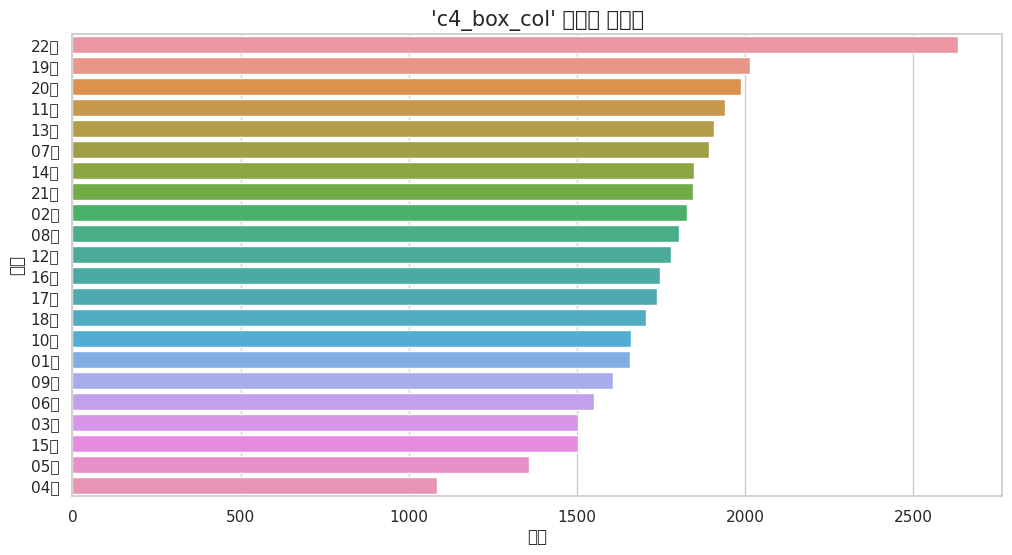

/home/piai/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/piai/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/piai/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/piai/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 48276 (\N{HANGUL SYLLABLE BEOM}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/piai/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from current font.
  fig.canvas.print_figure(bytes_i

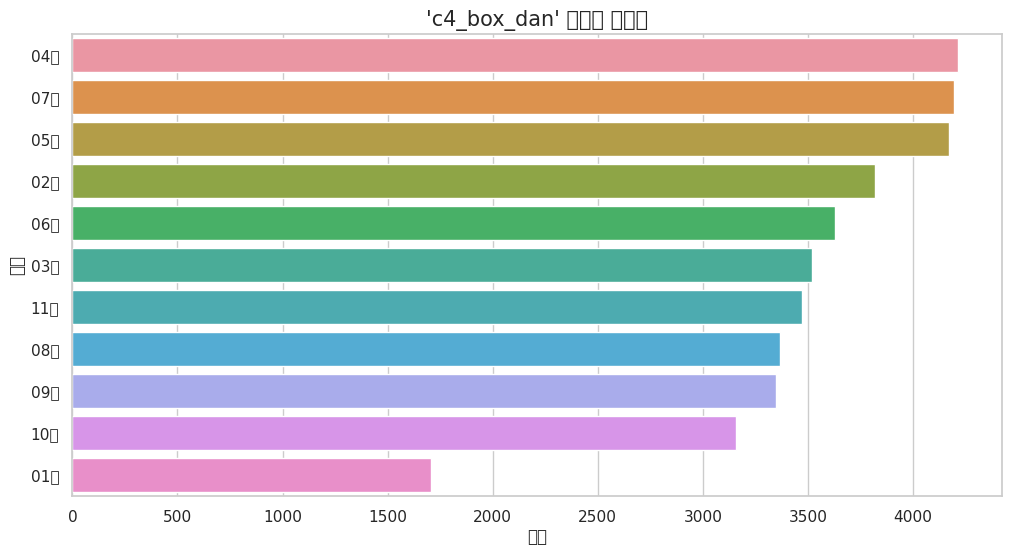

/home/piai/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/piai/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/piai/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 50676 (\N{HANGUL SYLLABLE YEOL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/piai/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 48276 (\N{HANGUL SYLLABLE BEOM}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/piai/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from current font.
  fig.canvas.print_figure(bytes_

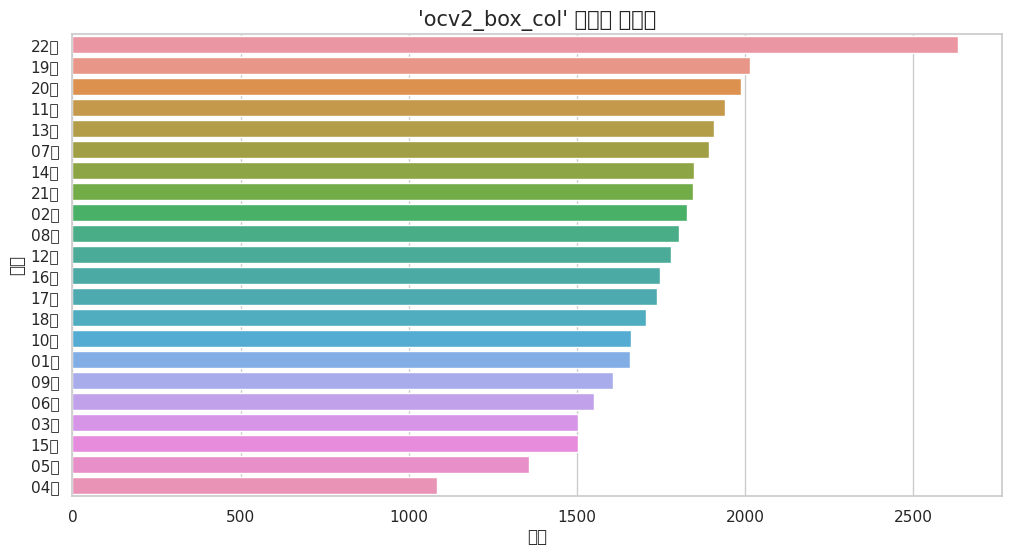

/home/piai/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/piai/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/piai/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/piai/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 48276 (\N{HANGUL SYLLABLE BEOM}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/piai/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from current font.
  fig.canvas.print_figure(bytes_i

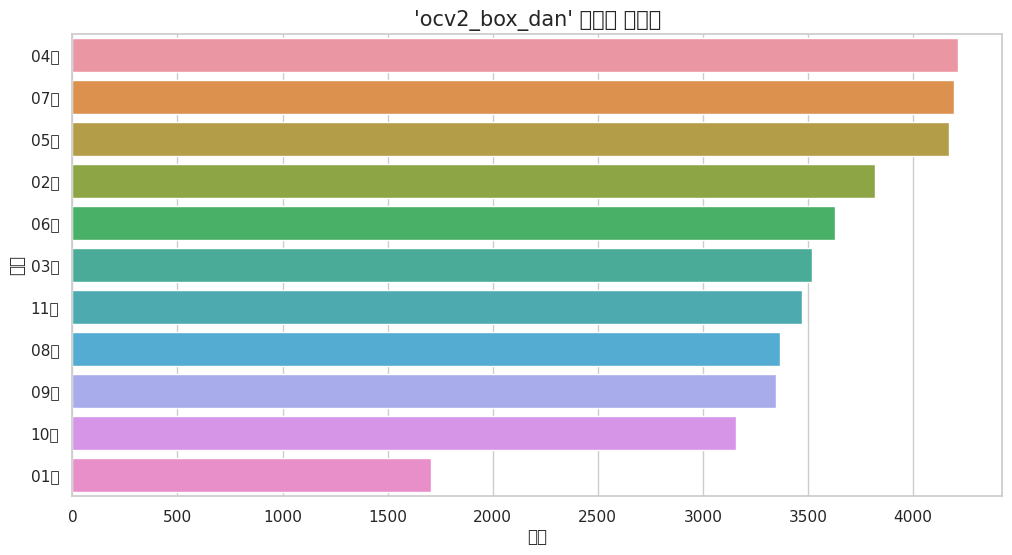

/home/piai/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/piai/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/piai/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 50676 (\N{HANGUL SYLLABLE YEOL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/piai/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 48276 (\N{HANGUL SYLLABLE BEOM}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/piai/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from current font.
  fig.canvas.print_figure(bytes_

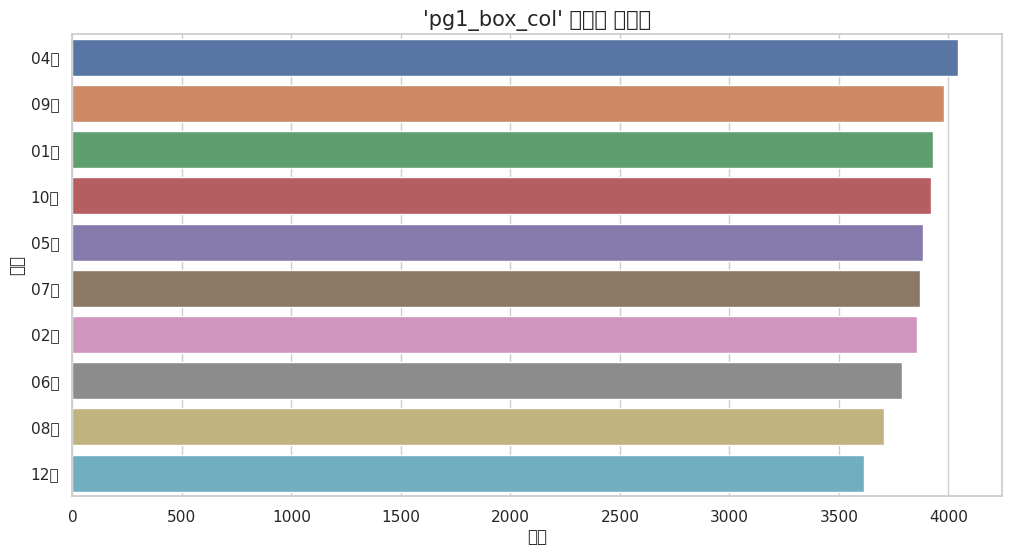

/home/piai/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/piai/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/piai/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/piai/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 48276 (\N{HANGUL SYLLABLE BEOM}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/piai/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from current font.
  fig.canvas.print_figure(bytes_i

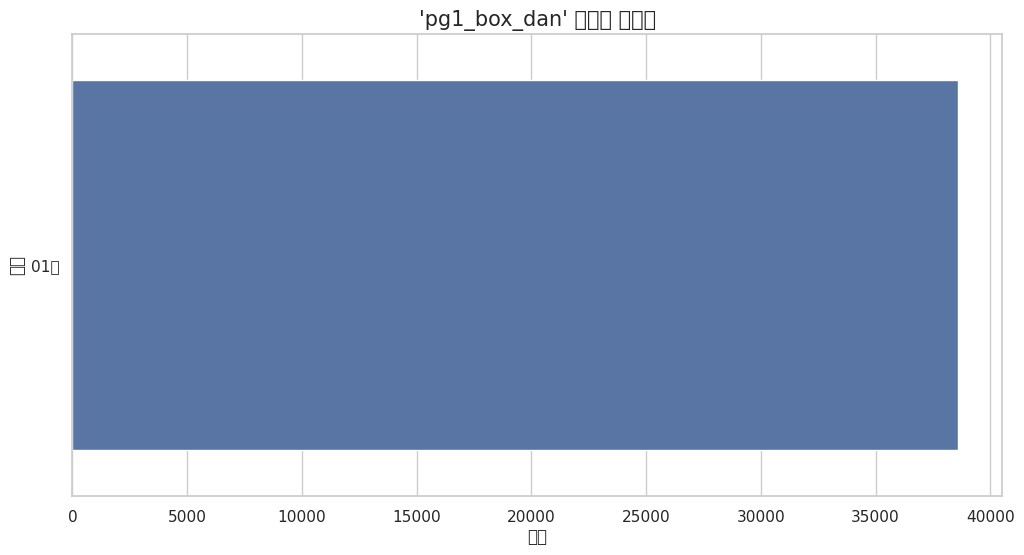

In [20]:


try:
    # .loc를 사용하여 분석할 컬럼 이름 목록을 가져옵니다.
    columns_to_check = df_은혁_object.loc[:, start_column:end_column].columns

    print("="*50)
    print(f"'{start_column}'부터 '{end_column}'까지 범주형 컬럼 빈도수 시각화")
    print("="*50)

    # 선택된 각 컬럼에 대해 반복문 실행
    for col in columns_to_check:
        # 고유 범주의 개수가 30개 미만일 때만 그래프를 그립니다.
        if df_은혁_object[col].nunique() < 30:
            plt.figure(figsize=(12, 6))
            # y축에 컬럼을 지정하여 가로 막대 그래프로 그립니다 (가독성 향상).
            sns.countplot(y=df_은혁_object[col], order=df_은혁_object[col].value_counts().index)
            plt.title(f"'{col}' 컬럼의 빈도수", fontsize=15)
            plt.xlabel("개수")
            plt.ylabel("범주")
            plt.show()
        else:
            print(f"\n--- 컬럼 '{col}'은(는) 고유 범주가 30개 이상이므로 그래프를 생략합니다. ---")
            # 대신 상위 10개 범주의 빈도수를 텍스트로 보여줍니다.
            print(df_은혁_object[col].value_counts().head(10))

except KeyError as e:
    print(f"에러 발생: {e}")
    print("\n[해결 방법]")
    print(f"'{str(e)}' 컬럼이 df_은혁_object 데이터프레임에 존재하는지 확인해주세요.")
    print("df_은혁_object.columns.tolist() 코드를 실행하여 실제 컬럼 목록을 확인하고,")
    print("start_column 또는 end_column 변수의 값을 정확한 이름으로 수정해주세요.")

except Exception as e:
    print(f"예상치 못한 에러가 발생했습니다: {e}")



In [21]:
df_은혁_int["pg1_imp"].unique()

array([2114, 2127, 2120, 2117, 2124, 2118, 2134, 2115, 2132, 2129, 2131,
       2111, 2137, 2122, 2112, 2100, 2133, 2158, 2126, 2128, 2113, 2139,
       2154, 2110, 2141, 2099, 2086, 2101, 2091, 2065, 2083, 2089, 2074,
       2072, 2079, 2097, 2059, 2093, 2088, 2064, 2108, 2102, 2098, 2092,
       2080, 2085, 2109, 2116, 2081, 2066, 2095, 2078, 2119, 2121, 2104,
       2138, 2062, 2136, 2063, 2047, 2054, 2042, 2068, 2032, 2052, 2069,
       2027, 2049, 2035, 2061, 2055, 2076, 2103, 2105, 2071, 2087, 2123,
       2082, 2107, 2096, 2106, 2090, 2125, 2075, 2094, 2140, 2165, 2169,
       2084, 2073, 2070, 2048, 2077, 2051, 2067, 2145, 2143, 2151, 2148,
       2144, 2146, 2150, 2130, 2135, 2057, 2037, 2028, 2044, 2058, 2039,
       2056, 2156, 2142, 2155, 2147, 2171, 2178, 2160, 2201, 2161, 2196,
       2187, 2163, 2192, 2170, 2188, 2194, 2168, 2177, 2153, 2166, 2045,
       2050, 2033, 2018, 2020, 2046, 2053, 2060, 2179, 2164, 2176, 2152,
       2184, 2172, 2157, 2181, 2162, 2173, 2159, 21

In [38]:
df_은혁_int["c4_ccval"].value_counts()

4085    786
4087    762
4079    751
4084    747
4086    745
       ... 
3201      1
4170      1
3343      1
3443      1
3075      1
Name: c4_ccval, Length: 211, dtype: int64